Machine Learning Project

In [13]:
!mamba install pandas == 1.3.3-y
!mamba install numpy ==1.21.2-y
!mamba install sklearn=0.20.1-y

'mamba' is not recognized as an internal or external command,
operable program or batch file.


'mamba' is not recognized as an internal or external command,
operable program or batch file.
'mamba' is not recognized as an internal or external command,
operable program or batch file.


In [14]:
%pip install piplite

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement piplite (from versions: none)

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for piplite


In [15]:
import numpy as np  
import pandas as pd  
import seaborn as sns  
from matplotlib import pyplot as plt

Develop Predication models

In [16]:
df = pd.read_csv('C:\\Users\\91830\\OneDrive\\Desktop\\Data Science\\Netflix Stock Price Prediction.csv')

df.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
lm = LinearRegression()
lm

LinearRegression()

In [19]:
x = df[['High']]
y = df['Volume']
lm.fit(x,y)

LinearRegression()

In [20]:
yhat = lm.predict(x)
yhat[0:5]

array([10725979.35758721, 10750031.44332805, 10634780.1370503 ,
       10731591.5750666 , 10968508.01301313])

In [21]:
lm.intercept_

16095687.924596129

In [22]:
lm.coef_

array([-20043.70543961])

In [23]:
#Equation of The Predicted line

yhat = -20043.70 + 16095687.92 * y 
yhat

0       1.914759e+14
1       2.027381e+14
2       1.445634e+14
3       1.497977e+14
4       2.721282e+14
            ...     
1004    3.226783e+14
1005    3.628338e+14
1006    2.309087e+14
1007    1.594310e+14
1008    1.252631e+14
Name: Volume, Length: 1009, dtype: float64

In [24]:
y__hat = -20043.70 + 16095687.92 * x
yhat

0       1.914759e+14
1       2.027381e+14
2       1.445634e+14
3       1.497977e+14
4       2.721282e+14
            ...     
1004    3.226783e+14
1005    3.628338e+14
1006    2.309087e+14
1007    1.594310e+14
1008    1.252631e+14
Name: Volume, Length: 1009, dtype: float64

In [25]:
z = df[['Close','Low','Volume','High','Adj Close']]

In [26]:
lm.fit(z,df['High'])

LinearRegression()

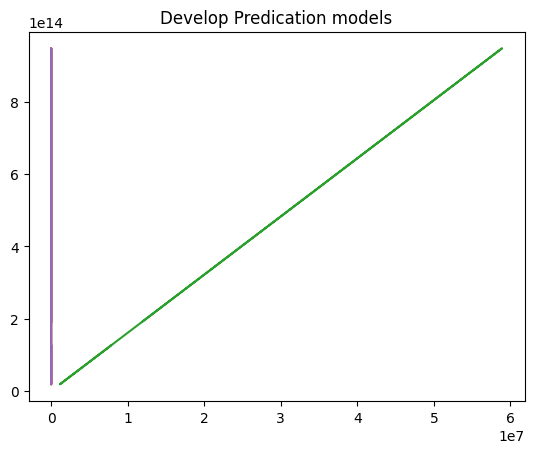

In [97]:
plt.title('Develop Predication models')
plt.plot(z,yhat)
plt.show()

#Model Evaluation Using Visualization

In [28]:
import seaborn as sns
%matplotlib inline

(0.0, 728.9901605018435)

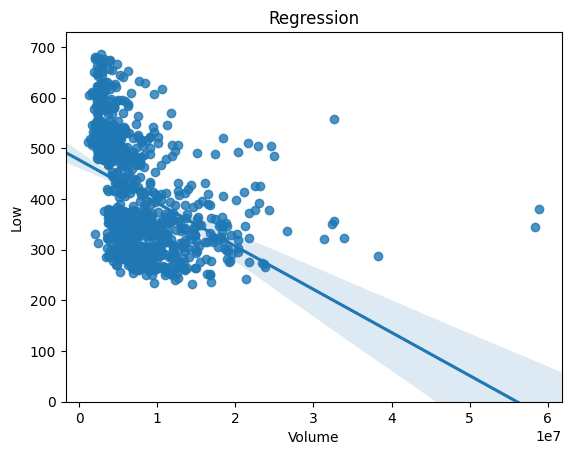

In [96]:
#Regression

increse=100
dicrease =85
plt.Figure(figsize=(increse,dicrease))
plt.title('Regression')
sns.regplot(x='Volume',y='Low',data=df)
plt.ylim(0,)

(0.0, 61803283.42640318)

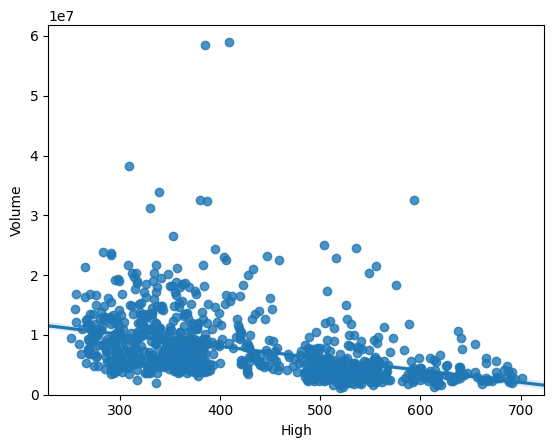

In [30]:
plt.Figure(figsize=(increse,dicrease))
sns.regplot(y='Volume',x='High',data=df)
plt.ylim(0,)

In [31]:
df[['High','Low','Volume']].corr()

,High,Low,Volume
High,1.000000,0.998203,-0.400699
Low,0.998203,1.000000,-0.432116
Volume,-0.400699,-0.432116,1.000000


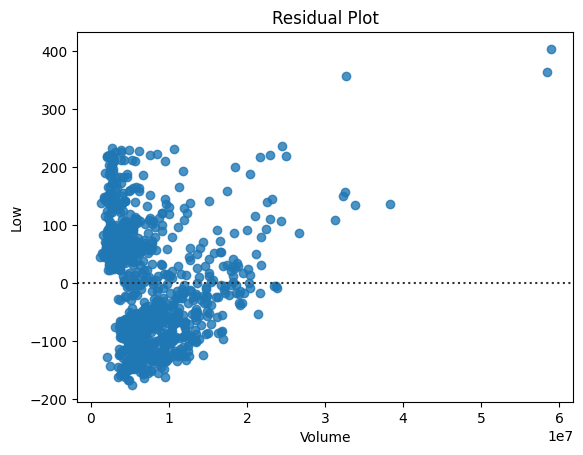

In [98]:
#Residual Plot
plt.Figure(figsize=(increse,dicrease))
plt.title('Residual Plot')
sns.residplot(x=df['Volume'],y=df['Low'])
plt.show()

In [33]:
#Mutiple Linear Regression

y_hat=lm.predict(z)
plt.Figure(figsize=(increse,dicrease))


<Figure size 10000x8500 with 0 Axes>

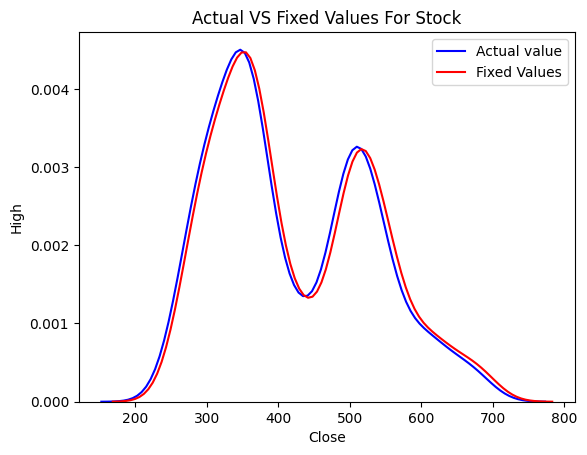

In [34]:
ax1 = sns.distplot(df['Close'], hist=False,color='b',label='Actual value')
sns.distplot(y_hat,hist=False,color='r',label='Fixed Values',ax=ax1)

plt.title('Actual VS Fixed Values For Stock')
plt.xlabel('Close')
plt.ylabel('High')
plt.show()

In [35]:
#Polynomial  Regressin and Pipelines

def plotpoly(model,independent_variable,dependent_variable,z):
    x_new= np.linspace(15,55,100)
    y_new= model(x_new)
    plt.plot(independent_variable,dependent_variable,'-', x_new,y_new,'-')


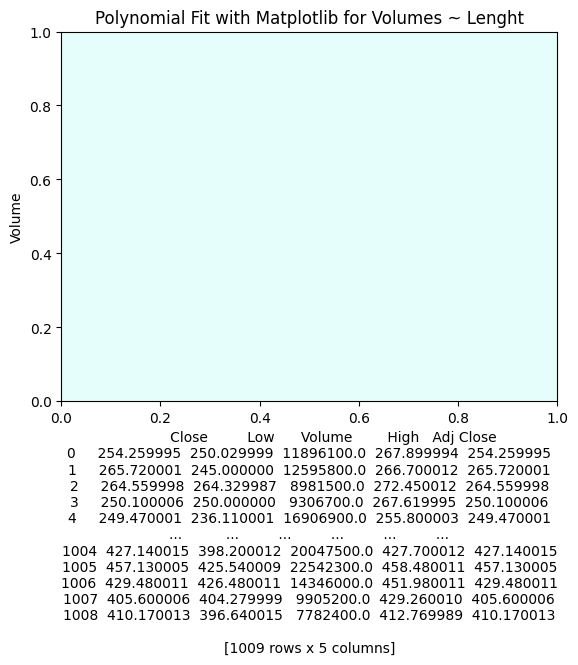

In [102]:
plt.title('Polynomial Fit with Matplotlib for Volumes ~ Lenght')
ax = plt.gca()
ax.set_facecolor((0.898,0.998,0.990))
fig = plt.gcf()
plt.xlabel(z)
plt.ylabel('Volume')
plt.show()

In [37]:
#Polynomial using the function Polyfit
x = df['Low']
y = df['Close']

In [38]:
#Polynomial of the 3rd order(cubic)
f = np.polyfit(x,y,8)
p = np.poly1d(f)
print(p)

           8            7             6           5             4
9.929e-18 x - 3.64e-14 x + 5.747e-11 x - 5.1e-08 x + 2.782e-05 x
             3         2
 - 0.009555 x + 2.018 x - 239 x + 1.231e+04


Text(0.5, 1.0, 'Polynomial of the 3rd order(cubic)')

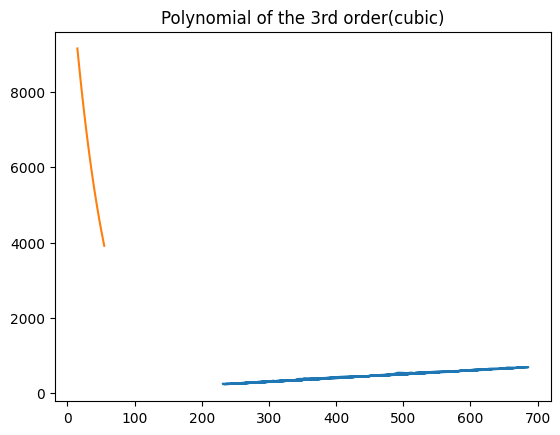

In [103]:
plotpoly(p,x,y,'Opne')
plt.title('Polynomial of the 3rd order(cubic)')

In [40]:
np.polyfit(x,y,3)

array([-2.69356731e-07,  3.62434458e-04,  8.49093402e-01,  2.59284892e+01])

In [41]:
from sklearn.preprocessing import PolynomialFeatures

In [42]:
#A Polynomial Feature object of Degree 2

pr = PolynomialFeatures(degree=2)

pr

PolynomialFeatures()

In [43]:
z_pr=pr.fit_transform(z)
z_pr.shape

(1009, 21)

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [45]:
#Pipeline: data pipelines simiplify the step od processing the data.

Input = [('scale',StandardScaler()),('polnomial',PolynomialFeatures(include_bias=False)),('model',LinearRegression())]

In [46]:
pipe = Pipeline(Input)
pipe

Pipeline(steps=[('scale', StandardScaler()),
                ('polnomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [47]:
#we can normalize the data , perform a tranform and fit the model simultaneously.
z = z.astype(float)
pipe.fit(z,y)

Pipeline(steps=[('scale', StandardScaler()),
                ('polnomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [48]:
#produce a prediction.
yPipe =pipe.predict(z)
yPipe[0:5]

array([254.259995, 265.720001, 264.559998, 250.100006, 249.470001])

In [49]:
from sklearn.metrics import mean_squared_error

In [50]:
mse = mean_squared_error(df['Volume'],yhat)
print('The mean  Squared error of volume and predicated value is:',mse)

The mean  Squared error of volume and predicated value is: 2.258005523997696e+28


#Multiple Linear Regression-R_Square

In [51]:


lm.fit(z,df['Close'])
print('The R-Squared is:',lm.score(z,df['Volume']))

The R-Squared is: -1.9203979186682436


In [52]:
y_predict_multifit = lm.predict(z)
print('The Mean square error of value and predicated value using multi fit is :',mean_squared_error(df['Volume'],y_predict_multifit))


The Mean square error of value and predicated value using multi fit is : 87151886337235.95


In [53]:
#Polynomial Fit - R2-score

from sklearn.metrics import r2_score

In [54]:
R_s = r2_score(y,p(x))
print('The R_Square value is:',R_s)

The R_Square value is: 0.9971318785077137


In [55]:
#MSE
mean_squared_error(df['Volume'],p(x))

87151907494166.06

Prediction And Decision Making

In [58]:
import matplotlib.pyplot as plt  
import numpy as np  
%matplotlib inline

In [85]:
new_in = np.arange(1,100,1).reshape(-2,1)


In [86]:
from sklearn.linear_model import LinearRegression

In [87]:
lm = LinearRegression()
lm

LinearRegression()

In [88]:
X=df[['Volume']]
Y=df['High']
lm.fit(X,Y)
lm

LinearRegression()

In [89]:
hat = lm.predict(new_in)
hat[0:5]

c:\Users\91830\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([485.96551554, 485.96550753, 485.96549952, 485.96549151,
       485.9654835 ])

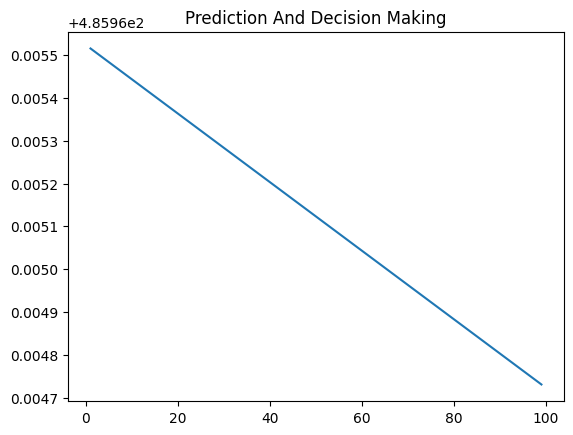

In [104]:
plt.plot(new_in,hat)
plt.title('Prediction And Decision Making')
plt.show()

In [92]:
from sklearn.metrics import mean_squared_error

In [95]:
#difference between actual value and the estimated value
MSError = mean_squared_error(new_in,hat)
MSError

190882.2682452333

the end project